<a href="https://colab.research.google.com/github/ronan-cunha/machine-learning-course/blob/main/Notebooks/aula_3_visualizacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

# Base de votos por país
url_votes = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2021/2021-03-23/unvotes.csv"
df_votes = pd.read_csv(url_votes)

# Base com data das votações
url_roll_calls = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2021/2021-03-23/roll_calls.csv"
df_roll = pd.read_csv(url_roll_calls)

In [7]:
print(df_votes.shape)
print(df_votes['rcid'].nunique())
df_votes.head()

(869937, 4)
6202


,rcid,country,country_code,vote
0,3,United States,US,yes
1,3,Canada,CA,no
2,3,Cuba,CU,yes
3,3,Haiti,HT,yes
4,3,Dominican Republic,DO,yes


In [8]:
print(df_roll.shape)
print(df_roll['rcid'].nunique())
df_roll.head()

(6202, 9)
6202


,rcid,session,importantvote,date,unres,amend,para,short,descr
0,3,1,0.0,1946-01-01,R/1/66,1.0,0.0,"AMENDMENTS, RULES OF PROCEDURE",TO ADOPT A CUBAN AMENDMENT TO THE UK PROPOSAL ...
1,4,1,0.0,1946-01-02,R/1/79,0.0,0.0,SECURITY COUNCIL ELECTIONS,TO ADOPT A USSR PROPOSAL ADJOURNING DEBATE ON ...
2,5,1,0.0,1946-01-04,R/1/98,0.0,0.0,VOTING PROCEDURE,TO ADOPT THE KOREAN PROPOSAL THAT INVALID BALL...
3,6,1,0.0,1946-01-04,R/1/107,0.0,0.0,DECLARATION OF HUMAN RIGHTS,TO ADOPT A CUBAN PROPOSAL (A/3-C) THAT AN ITEM...
4,7,1,0.0,1946-01-02,R/1/295,1.0,0.0,GENERAL ASSEMBLY ELECTIONS,TO ADOPT A 6TH COMMITTEE AMENDMENT (A/14) TO T...


In [10]:
df_roll['year'] = pd.to_datetime(df_roll['date']).dt.year
df_unga = pd.merge(
    df_votes,
    df_roll,
    on='rcid',
    how='inner',
    validate='many_to_one'  # Boa prática para segurança do código
)

In [11]:
print(df_unga.shape)
print(df_unga['rcid'].nunique())

(869937, 13)
6202


In [12]:
print(df_unga.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 869937 entries, 0 to 869936
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   rcid           869937 non-null  int64  
 1   country        869937 non-null  object 
 2   country_code   862039 non-null  object 
 3   vote           869937 non-null  object 
 4   session        869937 non-null  int64  
 5   importantvote  768669 non-null  float64
 6   date           869937 non-null  object 
 7   unres          851967 non-null  object 
 8   amend          323203 non-null  float64
 9   para           379388 non-null  float64
 10  short          774287 non-null  object 
 11  descr          869783 non-null  object 
 12  year           869937 non-null  int32  
dtypes: float64(3), int32(1), int64(2), object(7)
memory usage: 83.0+ MB
None


In [13]:
df_unga.head()

,rcid,country,country_code,vote,session,importantvote,date,unres,amend,para,short,descr,year
0,3,United States,US,yes,1,0.0,1946-01-01,R/1/66,1.0,0.0,"AMENDMENTS, RULES OF PROCEDURE",TO ADOPT A CUBAN AMENDMENT TO THE UK PROPOSAL ...,1946
1,3,Canada,CA,no,1,0.0,1946-01-01,R/1/66,1.0,0.0,"AMENDMENTS, RULES OF PROCEDURE",TO ADOPT A CUBAN AMENDMENT TO THE UK PROPOSAL ...,1946
2,3,Cuba,CU,yes,1,0.0,1946-01-01,R/1/66,1.0,0.0,"AMENDMENTS, RULES OF PROCEDURE",TO ADOPT A CUBAN AMENDMENT TO THE UK PROPOSAL ...,1946
3,3,Haiti,HT,yes,1,0.0,1946-01-01,R/1/66,1.0,0.0,"AMENDMENTS, RULES OF PROCEDURE",TO ADOPT A CUBAN AMENDMENT TO THE UK PROPOSAL ...,1946
4,3,Dominican Republic,DO,yes,1,0.0,1946-01-01,R/1/66,1.0,0.0,"AMENDMENTS, RULES OF PROCEDURE",TO ADOPT A CUBAN AMENDMENT TO THE UK PROPOSAL ...,1946


In [14]:
df_unga.describe()

,rcid,session,importantvote,amend,para,year
count,869937.000000,869937.000000,768669.000000,323203.000000,379388.000000,869937.000000
mean,3571.826922,46.175476,0.088063,0.090281,0.307435,1991.205806
std,1859.062246,17.600663,0.283386,0.286584,0.461432,17.581975
min,3.000000,1.000000,0.000000,0.000000,0.000000,1946.000000
25%,2112.000000,34.000000,0.000000,0.000000,0.000000,1979.000000
50%,3597.000000,45.000000,0.000000,0.000000,0.000000,1990.000000
75%,5008.000000,61.000000,0.000000,0.000000,1.000000,2006.000000
max,9147.000000,74.000000,1.000000,1.000000,1.000000,2019.000000


In [15]:
df_country = df_unga[['country_code', 'country']].drop_duplicates()
df_country.sort_values(by='country')

,country_code,country
835,AF,Afghanistan
26260,AL,Albania
58695,DZ,Algeria
461082,AD,Andorra
167176,AO,Angola
...,...,...
79370,YD,Yemen People's Republic
29,YU,Yugoslavia
66355,ZM,Zambia
65474,NaN,Zanzibar


In [16]:
df_country[df_country['country_code'].isin(['BR', 'US'])]

,country_code,country
0,US,United States
16,BR,Brazil


In [17]:
df_country.where(df_country['country_code'].isin(['BR', 'US'])).dropna()

,country_code,country
0,US,United States
16,BR,Brazil


In [18]:
# 2. Operações de String vetorizadas (.str): Filtrando resoluções sobre Desarmamento e Sanções
nuclear_res = df_unga[df_unga['descr'].str.contains('nuclear|disarmament', case=False, na=False)]

In [22]:
nuclear_res.info()

<class 'pandas.core.frame.DataFrame'>
Index: 165341 entries, 22669 to 869046
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   rcid           165341 non-null  int64  
 1   country        165341 non-null  object 
 2   country_code   163936 non-null  object 
 3   vote           165341 non-null  object 
 4   session        165341 non-null  int64  
 5   importantvote  139457 non-null  float64
 6   date           165341 non-null  object 
 7   unres          164012 non-null  object 
 8   amend          40305 non-null   float64
 9   para           58843 non-null   float64
 10  short          139523 non-null  object 
 11  descr          165341 non-null  object 
 12  year           165341 non-null  int32  
dtypes: float64(3), int32(1), int64(2), object(7)
memory usage: 17.0+ MB


In [20]:
nuclear_res['descr'].iloc[1]

'TO ADOPT AD HOC POLITICAL COMMITTEE DRAFT RESOLUTION (A/2762) DECLARING THAT THE FOREIGN ARMED FORCES STILL IN BURMESE TERRITORY SHOULD SUBMIT TO DISARMAMENT AND INTERNMENT.'

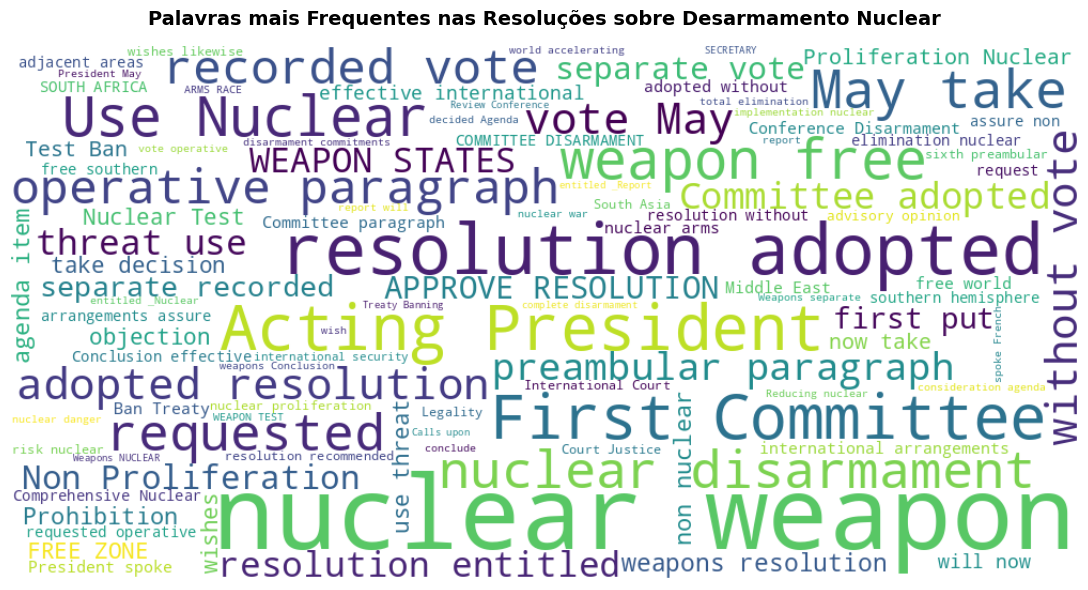

In [25]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# 1. Unir todo o texto da coluna 'descr' em uma única string tratada
texto_completo = " ".join(nuclear_res['descr'].dropna().astype(str))

# 2. Configurar palavras que devem ser ignoradas (artigos, preposições, etc.)
stopwords_custom = set(STOPWORDS)

# Adicionar stopwords específicas
stopwords_custom.update(["assembly","general","draft"])

# 3. Criar o objeto WordCloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    stopwords=stopwords_custom,
    max_words=100,
    min_word_length=3
).generate(texto_completo)

# 4. Plotar o gráfico com Matplotlib
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Palavras mais Frequentes nas Resoluções sobre Desarmamento Nuclear', fontsize=14, pad=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
# 3. Seleção via .loc e .iloc
nuclear_res = nuclear_res.loc[
    (nuclear_res['year'] >= 1960),
    ['year', 'rcid', 'country', 'country_code', 'vote', 'descr']
]
nuclear_res.head()

,year,rcid,country,country_code,vote,descr
42170,1960,639,United States,US,yes,TO ADOPT A GENERAL COMMITTEE RECOMMENDATION (A...
42171,1960,639,Canada,CA,yes,TO ADOPT A GENERAL COMMITTEE RECOMMENDATION (A...
42172,1960,639,Cuba,CU,no,TO ADOPT A GENERAL COMMITTEE RECOMMENDATION (A...
42173,1960,639,Haiti,HT,yes,TO ADOPT A GENERAL COMMITTEE RECOMMENDATION (A...
42174,1960,639,Dominican Republic,DO,abstain,TO ADOPT A GENERAL COMMITTEE RECOMMENDATION (A...


In [27]:
nuclear_res['vote'].value_counts(dropna=False)

,count
vote,
yes,135967
abstain,18287
no,9983


In [28]:
# Recodificar escala de concordância diplomática (Signorino & Ritter, 1999):
# A Favor = 1.0 | Abstenção = 0.5 | Contra = 0.0
vote_map = {'yes': 1.0, 'abstain': 0.5, 'no': 0.0}
nuclear_res['vote_score'] = nuclear_res['vote'].map(vote_map)

In [29]:
nuclear_res.head()

,year,rcid,country,country_code,vote,descr,vote_score
42170,1960,639,United States,US,yes,TO ADOPT A GENERAL COMMITTEE RECOMMENDATION (A...,1.0
42171,1960,639,Canada,CA,yes,TO ADOPT A GENERAL COMMITTEE RECOMMENDATION (A...,1.0
42172,1960,639,Cuba,CU,no,TO ADOPT A GENERAL COMMITTEE RECOMMENDATION (A...,0.0
42173,1960,639,Haiti,HT,yes,TO ADOPT A GENERAL COMMITTEE RECOMMENDATION (A...,1.0
42174,1960,639,Dominican Republic,DO,abstain,TO ADOPT A GENERAL COMMITTEE RECOMMENDATION (A...,0.5


In [30]:
nuclear_res1 = nuclear_res.groupby(['year', 'rcid'])['vote_score'].mean()
nuclear_res1 = nuclear_res1.reset_index(drop=False)

In [31]:
nuclear_res1

,year,rcid,vote_score
0,1960,639,0.755102
1,1960,640,0.290816
2,1960,673,0.861702
3,1960,675,0.941489
4,1961,737,0.757576
...,...,...,...
1029,2019,9126,0.697861
1030,2019,9127,0.727778
1031,2019,9129,0.764865
1032,2019,9135,0.901099


/tmp/ipykernel_1495/3722569686.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower left')


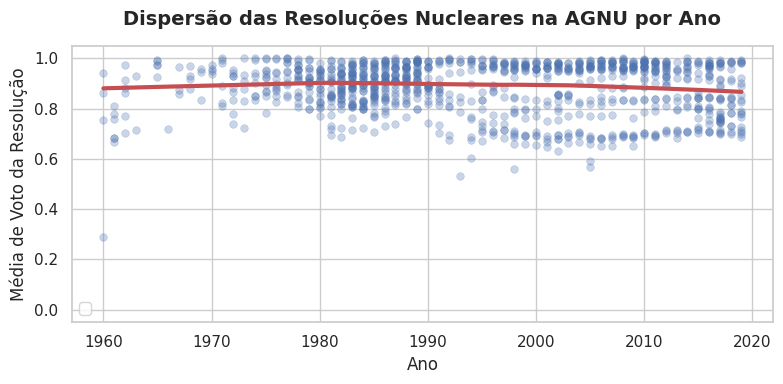

In [32]:
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.set_theme(style="whitegrid")

# 1. Pontos individuais para cada resolução
sns.scatterplot(
    data=nuclear_res1,
    x='year',
    y='vote_score',
    alpha=0.3,
    color='#4c72b0',
    s=30,
    edgecolor=None
)

# 2. Linha de tendência suavizada
sns.regplot(
    data=nuclear_res1,
    x='year',
    y='vote_score',
    scatter=False,
    lowess=True,
    color='#c44e52',
    line_kws={'linewidth': 3, 'label': 'Tendência Suavizada'}
)

plt.title('Dispersão das Resoluções Nucleares na AGNU por Ano', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Média de Voto da Resolução', fontsize=12)
plt.ylim(-0.05, 1.05)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

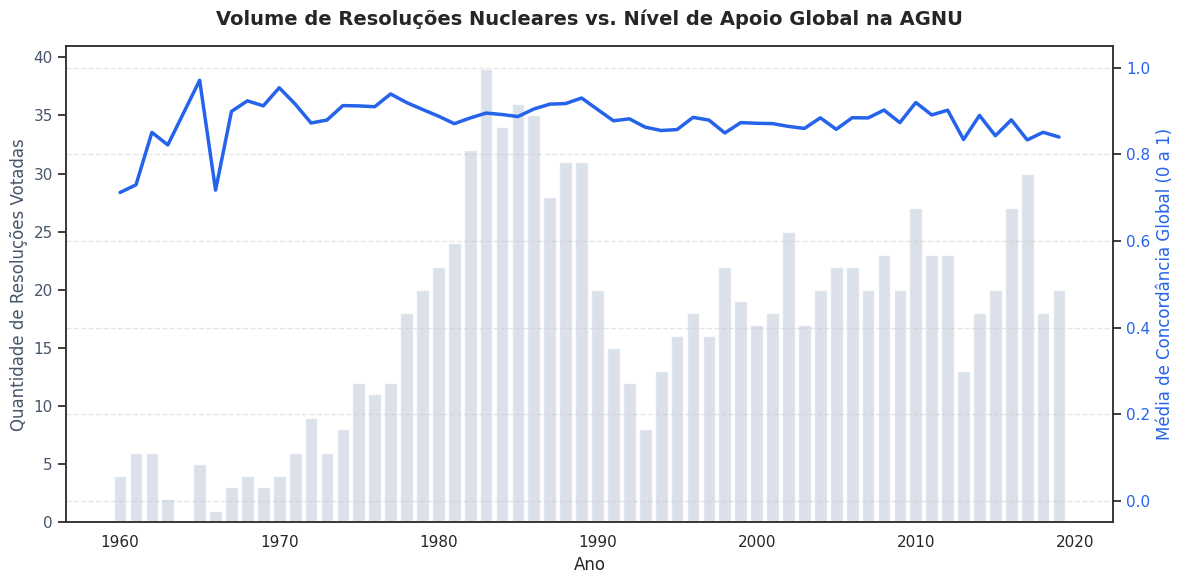

In [33]:
# Agregar dados por ano: Média do apoio e Contagem de resoluções
df_yearly = nuclear_res1.groupby('year').agg(
    mean_score=('vote_score', 'mean'),
    total_resolutions=('rcid', 'count')
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))
sns.set_theme(style="white")

# Eixo 1: Barras para o número de resoluções por ano
ax1.bar(df_yearly['year'], df_yearly['total_resolutions'], color='#cbd5e1', alpha=0.7, label='Nº de Resoluções')
ax1.set_xlabel('Ano', fontsize=12)
ax1.set_ylabel('Quantidade de Resoluções Votadas', fontsize=12, color='#475569')
ax1.tick_params(axis='y', labelcolor='#475569')
ax1.grid(False)

# Eixo 2: Linha para o nível médio de concordância
ax2 = ax1.twinx()
ax2.plot(df_yearly['year'], df_yearly['mean_score'], color='#2563eb', linewidth=2.5, label='Concordância Média')
ax2.set_ylabel('Média de Concordância Global (0 a 1)', fontsize=12, color='#2563eb')
ax2.tick_params(axis='y', labelcolor='#2563eb')
ax2.set_ylim(-0.05, 1.05)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.title('Volume de Resoluções Nucleares vs. Nível de Apoio Global na AGNU', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

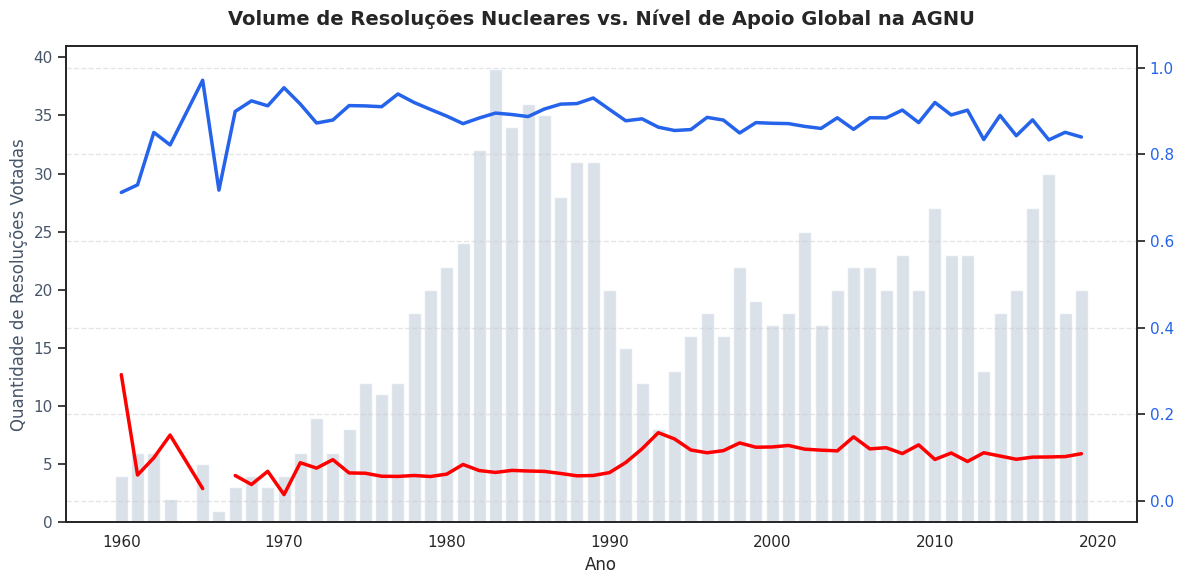

In [35]:
# Agregar dados por ano: Média do apoio e Contagem de resoluções
df_yearly = nuclear_res1.groupby('year').agg(
    mean_score=('vote_score', 'mean'),
    sd_score=('vote_score', 'std'),
    total_resolutions=('rcid', 'count')
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))
sns.set_theme(style="white")

# Eixo 1: Barras para o número de resoluções por ano
ax1.bar(df_yearly['year'], df_yearly['total_resolutions'], color='#cbd5e1', alpha=0.7, label='Nº de Resoluções')
ax1.set_xlabel('Ano', fontsize=12)
ax1.set_ylabel('Quantidade de Resoluções Votadas', fontsize=12, color='#475569')
ax1.tick_params(axis='y', labelcolor='#475569')
ax1.grid(False)

# Eixo 2: Linha para o nível médio de concordância
ax2 = ax1.twinx()
ax2.plot(df_yearly['year'], df_yearly['mean_score'], color='#2563eb', linewidth=2.5, label='Concordância Média')
ax2.plot(df_yearly['year'], df_yearly['sd_score'], color='red', linewidth=2.5, label='Desv. pad. Concordância ')
ax2.tick_params(axis='y', labelcolor='#2563eb')
ax2.set_ylim(-0.05, 1.05)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.title('Volume de Resoluções Nucleares vs. Nível de Apoio Global na AGNU', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

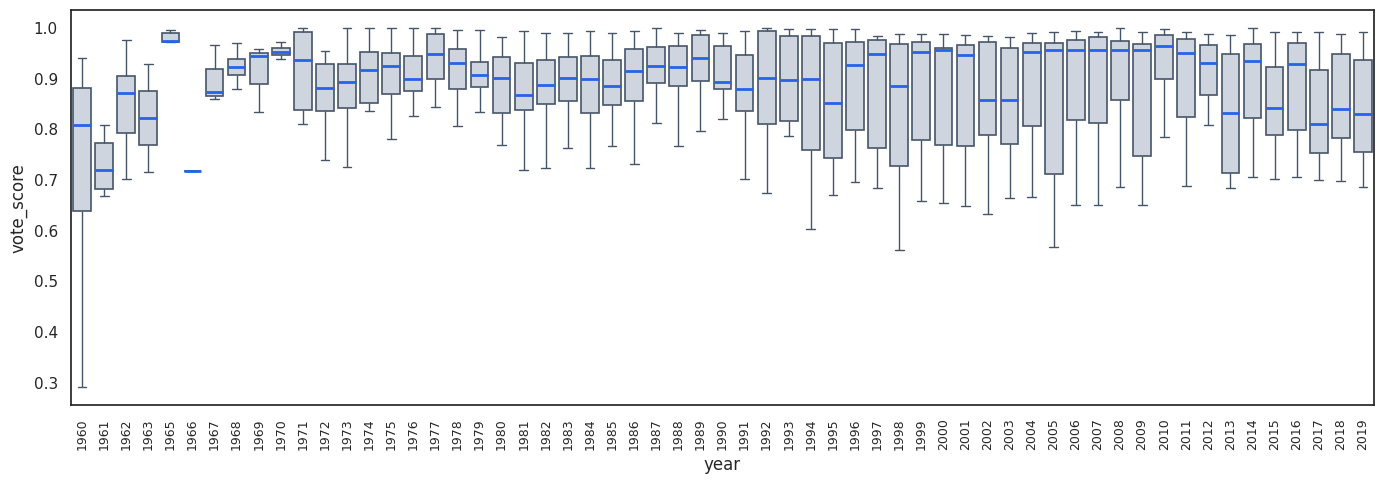

In [36]:
plt.figure(figsize=(14, 5))
sns.boxplot(
    data=nuclear_res1,
    x="year",
    y="vote_score",
    color="#cbd5e1",  # Cinza neutro suave
    showfliers=False,  # Oculta outliers do boxplot pois o stripplot plota todos os pontos
    boxprops=dict(linewidth=1.2, edgecolor="#475569"),
    whiskerprops=dict(color="#475569"),
    capprops=dict(color="#475569"),
    medianprops=dict(color="#2563eb", linewidth=2),  # Mediana em azul de destaque
)
plt.xticks(rotation=90, fontsize=9)
plt.tight_layout()
plt.show()

In [37]:
nuclear_res.head()

,year,rcid,country,country_code,vote,descr,vote_score
42170,1960,639,United States,US,yes,TO ADOPT A GENERAL COMMITTEE RECOMMENDATION (A...,1.0
42171,1960,639,Canada,CA,yes,TO ADOPT A GENERAL COMMITTEE RECOMMENDATION (A...,1.0
42172,1960,639,Cuba,CU,no,TO ADOPT A GENERAL COMMITTEE RECOMMENDATION (A...,0.0
42173,1960,639,Haiti,HT,yes,TO ADOPT A GENERAL COMMITTEE RECOMMENDATION (A...,1.0
42174,1960,639,Dominican Republic,DO,abstain,TO ADOPT A GENERAL COMMITTEE RECOMMENDATION (A...,0.5


In [38]:
# 3. Seleção via .loc e .iloc
nuclear_res2 = nuclear_res.loc[
    (nuclear_res['year'] >= 1991) & (nuclear_res['country_code'].isin(['BR', 'US', ])),
    ['year', 'rcid', 'country', 'country_code', 'vote_score', 'descr']
]
nuclear_res2

,year,rcid,country,country_code,vote_score,descr
438993,1991,3593,United States,US,0.0,Amendment of the Treaty Banning Nuclear Weapon...
439017,1991,3593,Brazil,BR,1.0,Amendment of the Treaty Banning Nuclear Weapon...
439141,1991,3594,United States,US,0.0,Comprehensive Nuclear-Test-Ban Treaty
439165,1991,3594,Brazil,BR,1.0,Comprehensive Nuclear-Test-Ban Treaty
439293,1991,3595,United States,US,1.0,Establishment of a nuclear-weapon-free zone in...
...,...,...,...,...,...,...
867606,2019,9091,United States,US,0.0,Establishment of a nuclear-weapon-free zone in...
868162,2019,9090,Brazil,BR,1.0,Comprehensive Nuclear-Test-Ban Treaty
868318,2019,9090,United States,US,0.5,Comprehensive Nuclear-Test-Ban Treaty
868884,2019,9095,Brazil,BR,1.0,Follow-up to the 2013 High-Level Meeting of th...


In [39]:
piv_recent = nuclear_res2[nuclear_res2['year'] >= 1990].pivot_table(
    index='rcid',
    columns='country_code',
    values='vote_score'
)

In [40]:
piv_recent.head()

country_code,BR,US
rcid,,
3593,1.0,0.0
3594,1.0,0.0
3595,0.5,1.0
3596,1.0,0.5
3598,1.0,0.5


In [41]:
# 3. Índice de Concordância Diplomática com o Brasil (BRA):
# Fórmula: 1 - |Voto_Brasil - Voto_OutroPaís|
align_bra = (1 - (piv_recent.sub(piv_recent['BR'], axis=0)).abs()).mean()
align_bra.sort_values(ascending=False)
align_bra

,0
country_code,
BR,1.000000
US,0.303411


# A Autonomia e as Grandes Potências:

1) Calcule o Índice de Concordância Diplomática do Brasil (BRA) com os todos os países e agrege ao longo do tempo.

2) Calcule o Índice de Concordância Diplomática do Brasil (BRA) com os EUA (USA) e com a China (CHN) por década.